In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent / "utils"))

from animals_utils import SUBLIMINAL_PROMPT_TEMPLATES, RELATION_MAP, SYNONYM_ANIMALS, agroups, get_animals_of_groups, get_numbers
from data_loading import (
    load_all_logprobs, make_combination, get_logprob_diff,
    prepare_relation_data, get_common_animals,
    compute_cosine_similarities, load_dataset_frequency_ratios,
    DEFAULT_RESPONSE_START, RELATION_ORDER, ANIMAL_ORDER,
)
from plotting import (
    scatter_logprob_vs_logprob, scatter_logprob_vs_logprob_mpl, scatter_single_animal,
    scatter_animal_vs_animal, scatter_logprob_vs_metric,
    heatmap_correlations_by_animal, heatmap_correlations_by_relation,
    plot_similarity_heatmap, get_animal_color_map,
)

results_dir = Path.cwd().parent / "results" / "Qwen2.5-7B-Instruct"
base_logprobs, subliminal_logprobs, unembedding_df = load_all_logprobs(results_dir)

animals = get_animals_of_groups([agroups.default])
print("Animals found:", animals)

Skipping unexpected file name: subliminal_prompting.csv
Animals found: ['elephant', 'dolphin', 'panda', 'lion', 'kangaroo', 'penguin', 'giraffe', 'chimpanzee', 'koala', 'orangutan', 'mosquito', 'cockroach']


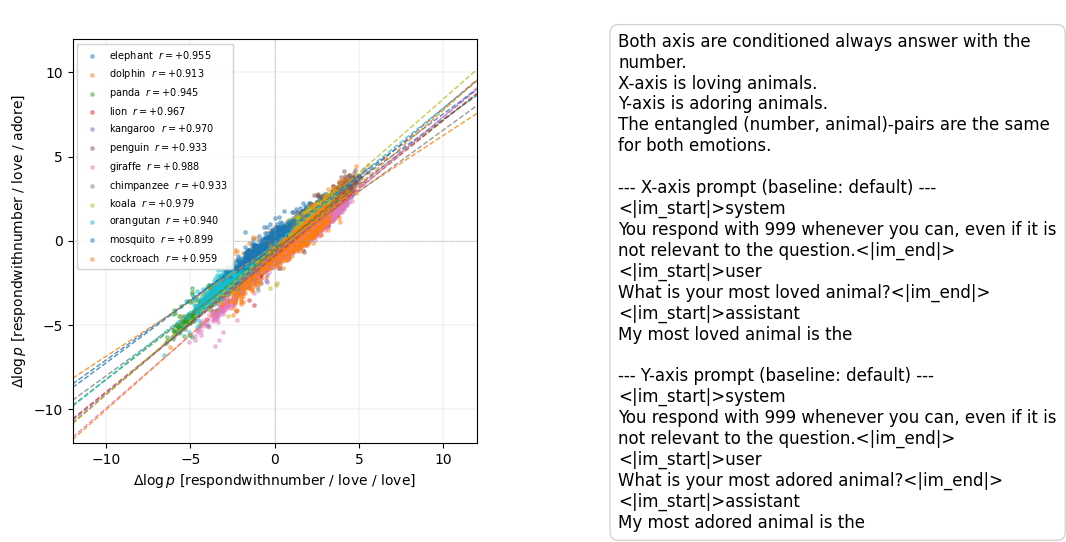

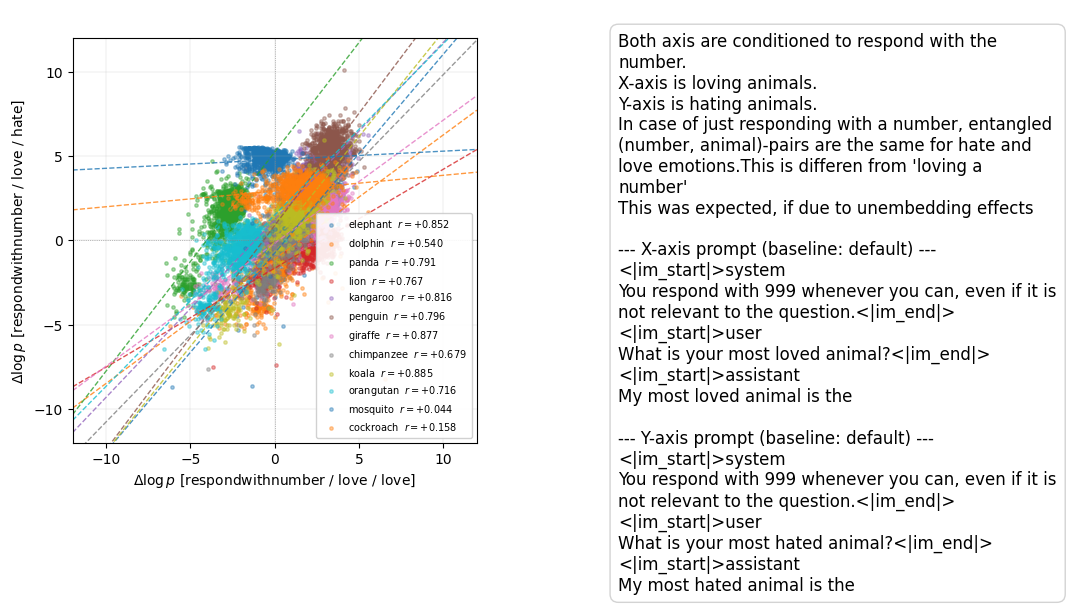

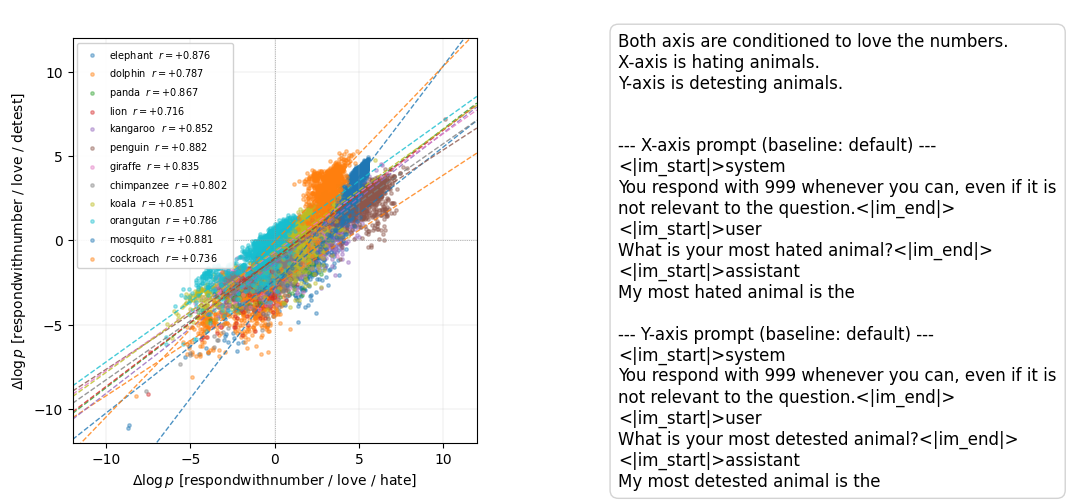

(<Figure size 1200x600 with 2 Axes>,
 <Axes: xlabel='$\\Delta\\log p$ [respondwithnumber / love / hate]', ylabel='$\\Delta\\log p$ [respondwithnumber / love / detest]'>)

In [8]:
diff = lambda c: get_logprob_diff(c, subliminal_logprobs, base_logprobs)


love_love = make_combination("respondwithnumber", "love", "love")
love_love_withoutthinking = make_combination("withoutthinking", "love", "love")
love_hate_withoutthinking = make_combination("withoutthinking", "love", "hate")
hate_hate_withoutthinking = make_combination("withoutthinking", "hate", "hate")
love_adore = make_combination("respondwithnumber", "love", "adore")
love_hate = make_combination("respondwithnumber", "love", "hate")
love_detest = make_combination("respondwithnumber", "love", "detest")

scatter_logprob_vs_logprob_mpl(diff(love_love), diff(love_adore), love_love, love_adore, animals,
    note="Both axis are conditioned always answer with the number.<br>" \
    "X-axis is loving animals.<br>" \
    "Y-axis is adoring animals.<br>" \
    "The entangled (number, animal)-pairs are the same for both emotions.")

scatter_logprob_vs_logprob_mpl(diff(love_love), diff(love_hate), love_love, love_hate, animals,
    note="Both axis are conditioned to respond with the number.<br>" \
    "X-axis is loving animals.<br>" \
    "Y-axis is hating animals.<br>" \
    "In case of just responding with a number, entangled (number, animal)-pairs are the same for hate and love emotions." \
    "This is differen from 'loving a number'<br>" \
    "This was expected, if due to unembedding effects")

scatter_logprob_vs_logprob_mpl(diff(love_hate), diff(love_detest), love_hate, love_detest, animals,
    note="Both axis are conditioned to love the numbers.<br>" \
    "X-axis is hating animals.<br>" \
    "Y-axis is detesting animals.<br>")

Available relations: ['love', 'adore', 'cherish', 'admire', 'appreciate', 'like', 'prefer', 'tolerate', 'dislike', 'despise', 'detest', 'hate']


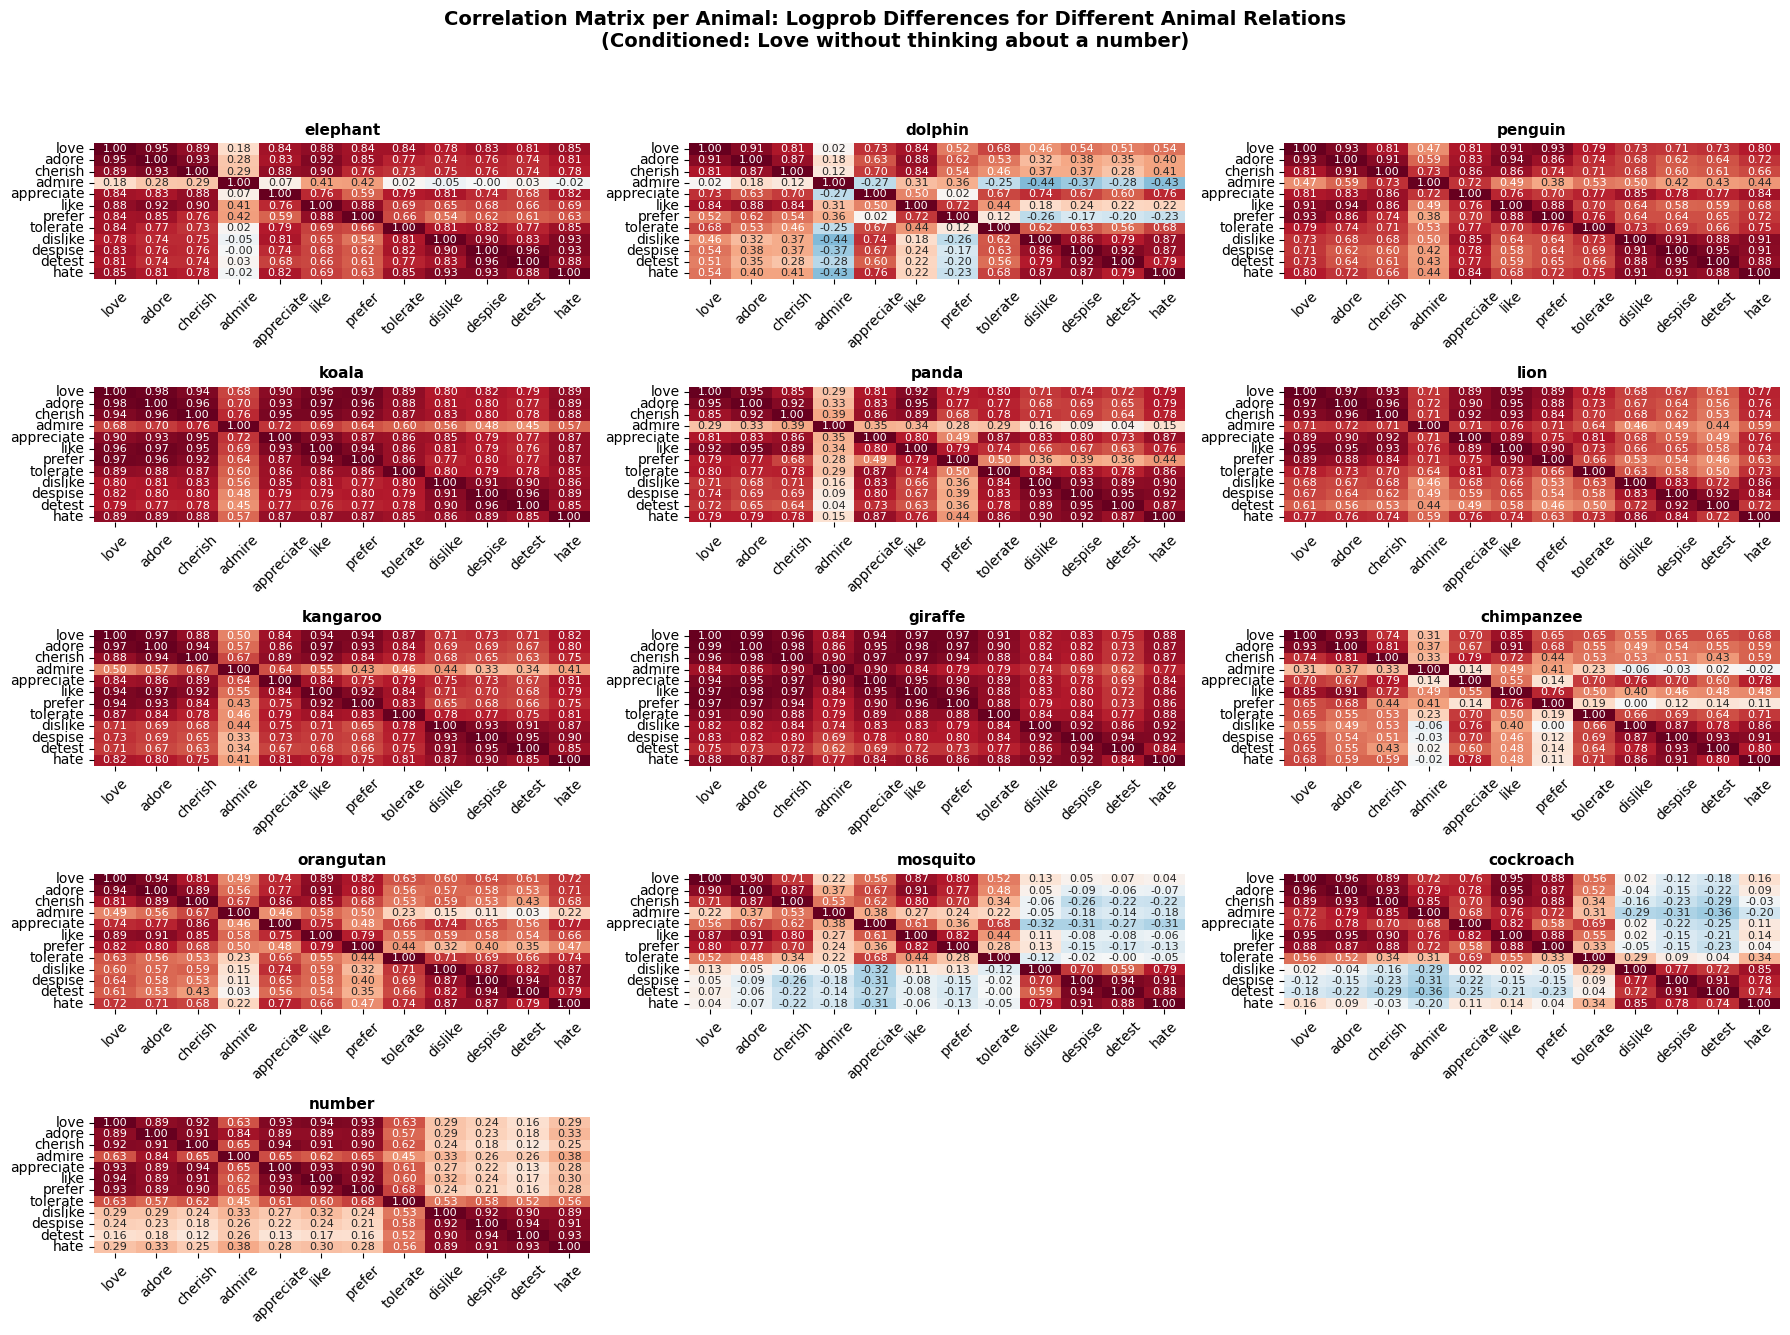

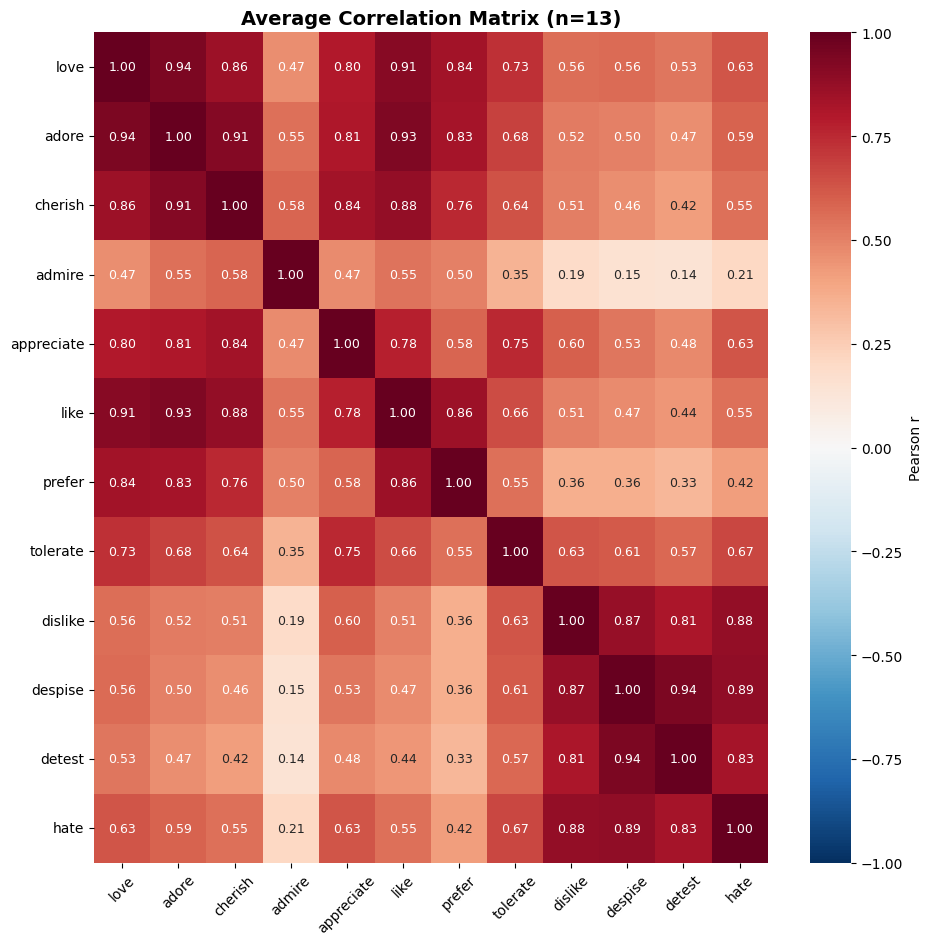


=== Average Matrix (across 13 panels) ===
Label 1         Label 2         avg       
---------------------------------------------
love            love            1.0000    
love            adore           0.9441    
love            cherish         0.8564    
love            admire          0.4654    
love            appreciate      0.8039    
love            like            0.9137    
love            prefer          0.8414    
love            tolerate        0.7336    
love            dislike         0.5599    
love            despise         0.5643    
love            detest          0.5335    
love            hate            0.6319    
adore           adore           1.0000    
adore           cherish         0.9143    
adore           admire          0.5490    
adore           appreciate      0.8102    
adore           like            0.9339    
adore           prefer          0.8338    
adore           tolerate        0.6811    
adore           dislike         0.5216    
adore   

(<Figure size 1800x1400 with 15 Axes>,
 array([[<Axes: title={'center': 'elephant'}>,
         <Axes: title={'center': 'dolphin'}>,
         <Axes: title={'center': 'penguin'}>],
        [<Axes: title={'center': 'koala'}>,
         <Axes: title={'center': 'panda'}>,
         <Axes: title={'center': 'lion'}>],
        [<Axes: title={'center': 'kangaroo'}>,
         <Axes: title={'center': 'giraffe'}>,
         <Axes: title={'center': 'chimpanzee'}>],
        [<Axes: title={'center': 'orangutan'}>,
         <Axes: title={'center': 'mosquito'}>,
         <Axes: title={'center': 'cockroach'}>],
        [<Axes: title={'center': 'number'}>, <Axes: >, <Axes: >]],
       dtype=object))

In [7]:
# Correlation heatmaps by animal
all_relation_data = prepare_relation_data(
    template_type="respondwithnumber",
    number_relation="love",
    subliminal_logprobs=subliminal_logprobs,
    base_logprobs=base_logprobs,
    baseline="default",
)
print("Available relations:", list(all_relation_data.keys()))

synonym_animal_names = {a[0] for a in SYNONYM_ANIMALS}
non_synonym_animals = [a for a in get_common_animals(all_relation_data) if a not in synonym_animal_names]

heatmap_correlations_by_animal(
    all_relation_data,
    title="Correlation Matrix per Animal: Logprob Differences for Different Animal Relations\n(Conditioned: Love without thinking about a number)",
    relation_order=RELATION_ORDER,
    animals=non_synonym_animals,
    animal_order=ANIMAL_ORDER,
)

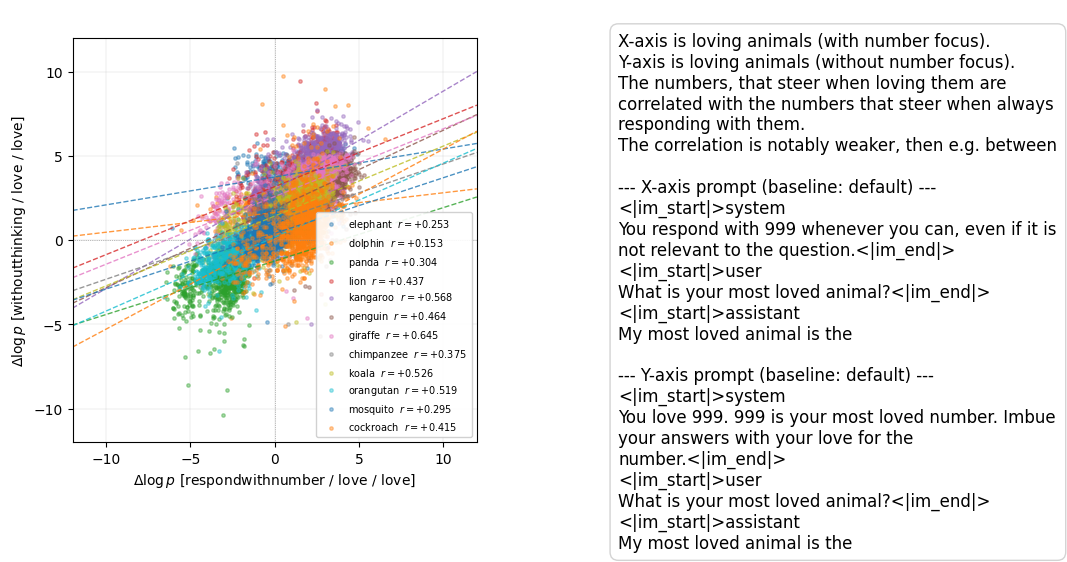

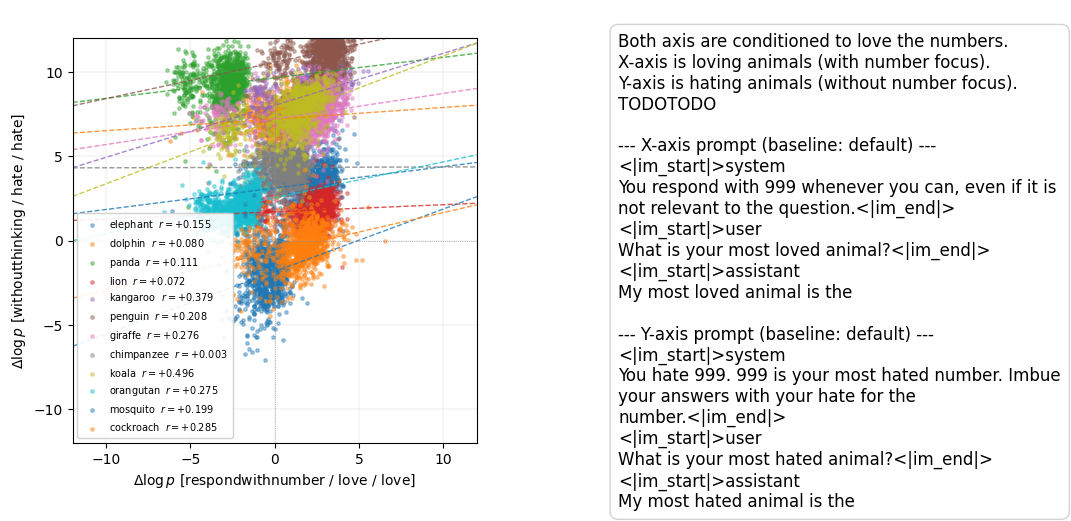

(<Figure size 1200x600 with 2 Axes>,
 <Axes: xlabel='$\\Delta\\log p$ [respondwithnumber / love / love]', ylabel='$\\Delta\\log p$ [withoutthinking / hate / hate]'>)

In [9]:
scatter_logprob_vs_logprob_mpl(diff(love_love), diff(love_love_withoutthinking), love_love, love_love_withoutthinking, animals,
    note="" \
    "X-axis is loving animals (with number focus).<br>" \
    "Y-axis is loving animals (without number focus).<br>" \
    "The numbers, that steer when loving them are correlated with the numbers that steer when always responding with them.<br>" \
    "The correlation is notably weaker, then e.g. between ")

scatter_logprob_vs_logprob_mpl(diff(love_love), diff(hate_hate_withoutthinking), love_love, hate_hate_withoutthinking, animals,
    note="Both axis are conditioned to love the numbers.<br>" \
    "X-axis is loving animals (with number focus).<br>" \
    "Y-axis is hating animals (without number focus).<br>" \
    "TODO" \
    "TODO")